In [1]:
import time
import PIL.Image
import numpy as np 
import tensorflow as tf
import matplotlib.pyplot as plt
import IPython.display as display
#from IPython.display import display, clear_output

In [5]:
class StyleContentModel(tf.keras.models.Model):
  def vgg_layers(eelf,layer_names):
      vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')
      vgg.trainable = False
      outputs = [vgg.get_layer(name).output for name in layer_names]
      model = tf.keras.Model([vgg.input], outputs)
      return model
  def __init__(self, style_layers, content_layers):
    super(StyleContentModel, self).__init__() 
    self.vgg = self.vgg_layers(style_layers + content_layers)
    self.style_layers = style_layers
    self.content_layers = content_layers
    self.num_style_layers = len(style_layers)
    self.vgg.trainable = False

  def gram_matrix(self,input_tensor):
    result = tf.linalg.einsum('bijc,bijd->bcd', input_tensor, input_tensor)
    input_shape = tf.shape(input_tensor)
    num_locations = tf.cast(input_shape[1]*input_shape[2], tf.float32)
    return result/(num_locations)

  def call(self, inputs):
    inputs = inputs*255.0
    preprocessed_input = tf.keras.applications.vgg19.preprocess_input(inputs)
    outputs = self.vgg(preprocessed_input)
    style_outputs, content_outputs = (outputs[:self.num_style_layers],
                                      outputs[self.num_style_layers:])

    style_outputs = [self.gram_matrix(style_output)
                     for style_output in style_outputs]

    content_dict = {content_name: value
                    for content_name, value
                    in zip(self.content_layers, content_outputs)}

    style_dict = {style_name: value
                  for style_name, value
                  in zip(self.style_layers, style_outputs)}

    return {'content': content_dict, 'style': style_dict}

In [44]:
class StyleTransfer:
  style_layers = ['block1_conv1', 'block2_conv1', 'block3_conv1', 'block4_conv1', 'block5_conv1']
  content_layers = ['block5_conv2']
  def __init__(self, link_style_path, link_content_path, img_size=512, style_weight=1e-2, content_weight=1e4, total_variation_weight = 30, epochs = 10, steps_per_epoch=100):
    self.style_path = tf.keras.utils.get_file(origin = link_content_path)
    self.content_path = tf.keras.utils.get_file(origin = link_style_path)
    self.img_size = img_size
    self.style_weight = style_weight
    self.content_weight = content_weight
    self.total_variation_weight = total_variation_weight
    self.epochs = epochs
    self.steps_per_epoch = steps_per_epoch
    self.extractor = StyleContentModel(StyleTransfer.style_layers,StyleTransfer.content_layers)

    self.num_content_layers = len(StyleTransfer.content_layers)
    self.num_style_layers = len(StyleTransfer.style_layers)
    self.style_image = self.load_img(self.style_path)
    self.content_image = self.load_img(self.content_path)
    self.image = tf.Variable(self.content_image)
    self.total_variation_loss = self.total_variation_loss(self.image).numpy()
    self.total_variation_loss2 = tf.image.total_variation(self.image).numpy()[0]
  def load_img(self, path_to_img):
    img = tf.io.read_file(path_to_img)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)

    shape = tf.cast(tf.shape(img)[:-1], tf.float32)
    long_dim = max(shape)
    scale = self.img_size / long_dim

    new_shape = tf.cast(shape * scale, tf.int32)

    img = tf.image.resize(img, new_shape)
    img = img[tf.newaxis, :]
    return img 
  def imshow(self,image, title=None):
    if len(image.shape) > 3:
      image = tf.squeeze(image, axis=0)

    plt.imshow(image)
    if title:
      plt.title(title)
  def imshow_content_style(self):
    plt.subplot(1, 2, 1)
    self.imshow(self.content_image, 'Content Image')

    plt.subplot(1, 2, 2)
    self.imshow(self.style_image, 'Style Image')
    
  def tensor_to_image(self,tensor):
    tensor = tensor*255
    tensor = np.array(tensor, dtype=np.uint8)
    if np.ndim(tensor)>3:
      assert tensor.shape[0] == 1
      tensor = tensor[0]
    return PIL.Image.fromarray(tensor)

  def clip_0_1(self,image):
    return tf.clip_by_value(image, clip_value_min=0.0, clip_value_max=1.0)
  def run_gradient(self):
    
    style_targets = self.extractor(self.style_image)['style']
    content_targets = self.extractor(self.content_image)['content']

    opt = tf.keras.optimizers.Adam(learning_rate=0.02, beta_1=0.99, epsilon=1e-1)

    def style_content_loss(outputs):
      style_outputs = outputs['style']
      content_outputs = outputs['content']
      style_loss = tf.add_n([tf.reduce_mean((style_outputs[name]-style_targets[name])**2) 
                            for name in style_outputs.keys()])
      style_loss *= self.style_weight / self.num_style_layers

      content_loss = tf.add_n([tf.reduce_mean((content_outputs[name]-content_targets[name])**2) 
                              for name in content_outputs.keys()])
      content_loss *= self.content_weight / self.num_content_layers
      loss = style_loss + content_loss
      return loss

    @tf.function()
    def train_step(image):
      with tf.GradientTape() as tape:
        outputs = self.extractor(image)
        loss = style_content_loss(outputs)
        loss += self.total_variation_weight*tf.image.total_variation(image)
      grad = tape.gradient(loss, image)
      opt.apply_gradients([(grad, image)])
      image.assign(self.clip_0_1(image))

    start = time.time()
    step = 0
    for n in range(self.epochs):
      for m in range(self.steps_per_epoch):
        step += 1
        train_step(self.image)
        print(".", end='', flush=True)
      display.clear_output(wait=True)
      display.display(self.tensor_to_image(self.image))
      print("Train step: {}".format(step))
      
    end = time.time()
    print("Total time: {:.1f}".format(end-start))
  
  def save_image(self, name = None, img_format='png'):
    if name:
      file_name = name + '.' +  img_format
    else:
      file_name = 'stylized-image.' +  img_format

    self.tensor_to_image(self.image).save(file_name)
    try:
      from google.colab import files
    except ImportError:
      pass
    else:
      files.download(file_name)
  def high_pass_x_y(self, image):
      x_var = image[:, :, 1:, :] - image[:, :, :-1, :]
      y_var = image[:, 1:, :, :] - image[:, :-1, :, :]
      return x_var, y_var
  def main_strokes(self):
    x_deltas, y_deltas = self.high_pass_x_y(self.content_image)

    plt.figure(figsize=(14, 10))
    plt.subplot(2, 2, 1)
    self.imshow(self.clip_0_1(2*y_deltas+0.5), "Horizontal Deltas: Original")

    plt.subplot(2, 2, 2)
    self.imshow(self.clip_0_1(2*x_deltas+0.5), "Vertical Deltas: Original")

    x_deltas, y_deltas = self.high_pass_x_y(self.image)

    plt.subplot(2, 2, 3)
    self.imshow(self.clip_0_1(2*y_deltas+0.5), "Horizontal Deltas: Styled")

    plt.subplot(2, 2, 4)
    self.imshow(self.clip_0_1(2*x_deltas+0.5), "Vertical Deltas: Styled")
  def total_variation_loss(self,image):
    x_deltas, y_deltas = self.high_pass_x_y(image)
    return tf.reduce_sum(tf.abs(x_deltas)) + tf.reduce_sum(tf.abs(y_deltas))

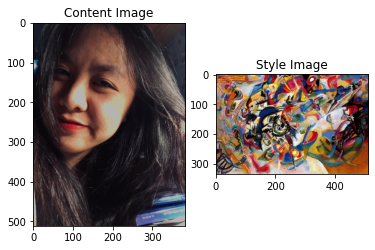

In [45]:
x = 'https://i.ibb.co/rGS42y1/Anh-2.jpg'
# y = 'https://i.ibb.co/7kFyzWn/background-vintage-14.jpg'
y = 'https://storage.googleapis.com/download.tensorflow.org/example_images/Vassily_Kandinsky%2C_1913_-_Composition_7.jpg'
st = StyleTransfer(x, y,epochs=5,steps_per_epoch=50)
st.imshow_content_style()

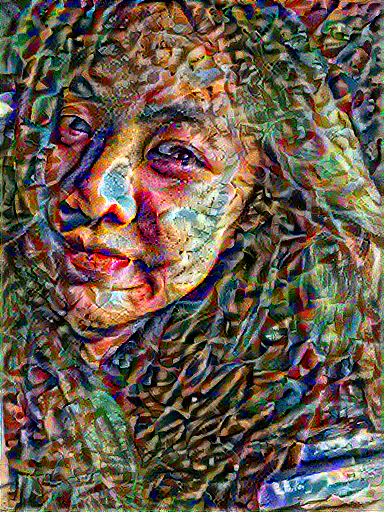

Train step: 250
Total time: 19.7


In [46]:
st.run_gradient()

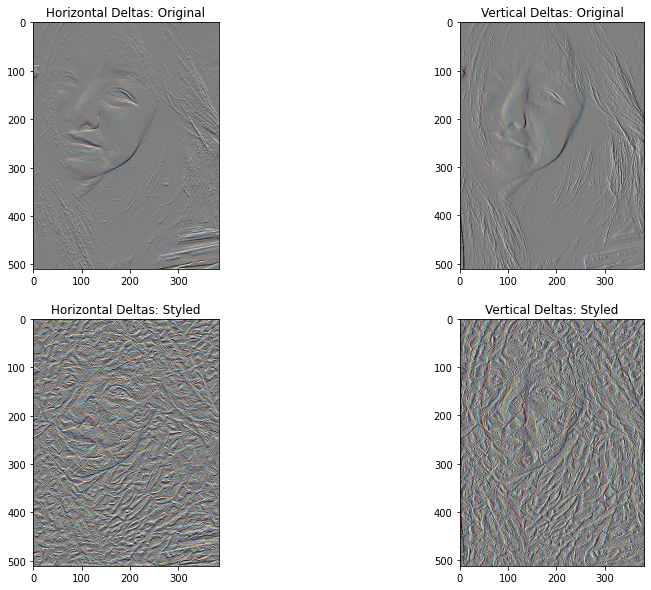

In [47]:
st.main_strokes()

In [48]:
st.total_variation_loss

28324.93

In [49]:
st.total_variation_loss2

28324.93

In [51]:
st.save_image()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>